<b>UDASCO, DANIEL A. | T09-A |</b> <br>
Binary Classification Model Using Convolutional Neural Network

# Import Libraries and Packages

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers, models

<h1>Split the Dataset</h1>

In [2]:
BATCH_SIZE = 32
IMG_SIZE = (128,128)  
DATA_DIR = 'dataset'

# Split dataset into training and validation sets.
# For Training set: 80%
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# For Validation set: 20%
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 10951 files belonging to 2 classes.
Using 8761 files for training.
Found 10951 files belonging to 2 classes.
Using 2190 files for validation.


# Normalization

In [3]:
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Optimization

In [4]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

<h1>Modeling</h1>

In [5]:
model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Conv2D(32,(3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

# Compiling

In [6]:
model.compile(
    optimizer='adam',               
    loss='binary_crossentropy',      
    metrics=['accuracy']             
)

<h1>Training</h1>

In [7]:
epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 125ms/step - accuracy: 0.6515 - loss: 0.6448 - val_accuracy: 0.6913 - val_loss: 0.5850
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 126ms/step - accuracy: 0.7393 - loss: 0.5313 - val_accuracy: 0.7342 - val_loss: 0.5330
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 37s 135ms/step - accuracy: 0.7850 - loss: 0.4516 - val_accuracy: 0.7548 - val_loss: 0.5125
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 38s 137ms/step - accuracy: 0.8280 - loss: 0.3833 - val_accuracy: 0.7922 - val_loss: 0.4863
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 37s 136ms/step - accuracy: 0.8566 - loss: 0.3234 - val_accuracy: 0.7858 - val_loss: 0.5303
Epoch 6/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 37s 136ms/step - accuracy: 0.8905 - loss: 0.2576 - val_accuracy: 0.7959 - val_loss: 0.5819
Epoch 7/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 38s 139ms/step - accuracy: 0.9240 - loss: 0.1891 - val_accuracy: 0.8073 - val_loss: 0.5870
Epoch 8/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 39s 142ms/step - accuracy: 0.9442 - loss: 0

<h1>Plot Training and Validation Accuracy and Loss</h1>

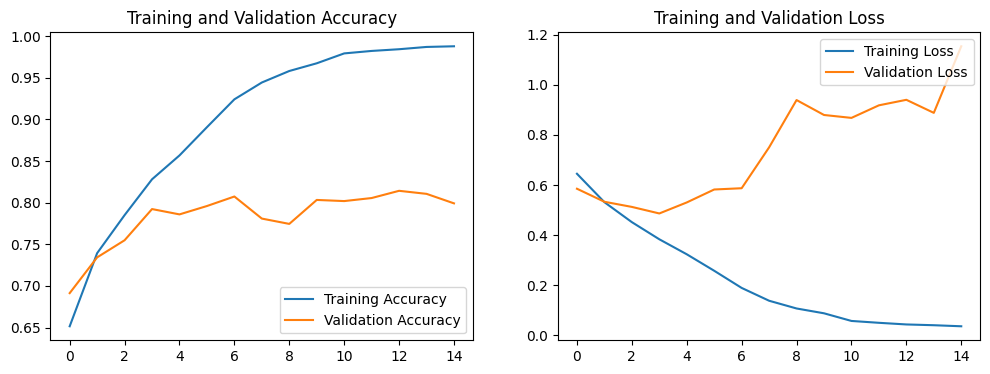

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

<h1>Images Prediction</h1>

## Predict male1.jpg image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
RESULT: Pen
accuracy: 100.00%


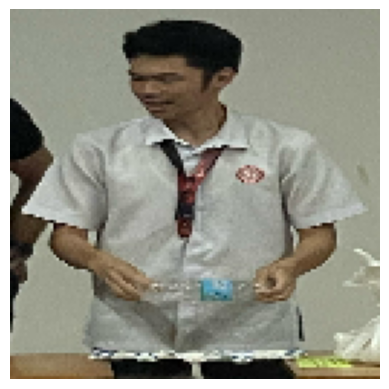

In [9]:
image_path = 'male_female_pic/male1.jpg'

img = tf.keras.utils.load_img(
    image_path, target_size=(128, 128)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0) 

img_array = img_array / 255.0

predictions = model.predict(img_array)
score = predictions[0][0]

if score > 0.5:
    print(f"RESULT: Pencil")
    print(f"accuracy: {100 * score:.2f}%")
else:
    print(f"RESULT: Pen")
    print(f"accuracy: {100 * (1 - score):.2f}%")

import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')
plt.show()

## Predict female1 image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
RESULT: Pen
accuracy: 100.00%


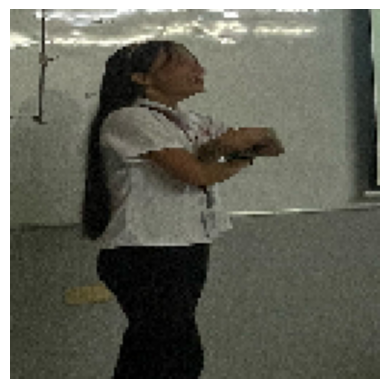

In [10]:
image_path = 'male_female_pic/female1.jpg'

img = tf.keras.utils.load_img(
    image_path, target_size=(128, 128)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0) 

img_array = img_array / 255.0

predictions = model.predict(img_array)
score = predictions[0][0]

if score > 0.5:
    print(f"RESULT: Pencil")
    print(f"accuracy: {100 * score:.2f}%")
else:
    print(f"RESULT: Pen")
    print(f"accuracy: {100 * (1 - score):.2f}%")

import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')
plt.show()

## Predict male2.jpg image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
RESULT: Pen
accuracy: 98.61%


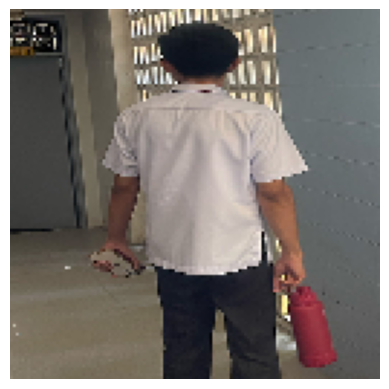

In [11]:
image_path = 'male_female_pic/male2.jpg'

img = tf.keras.utils.load_img(
    image_path, target_size=(128, 128)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0) 

img_array = img_array / 255.0

predictions = model.predict(img_array)
score = predictions[0][0]

if score > 0.5:
    print(f"RESULT: Pencil")
    print(f"accuracy: {100 * score:.2f}%")
else:
    print(f"RESULT: Pen")
    print(f"accuracy: {100 * (1 - score):.2f}%")

import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')
plt.show()

## Predict female2.jpg image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
RESULT: Pen
accuracy: 100.00%


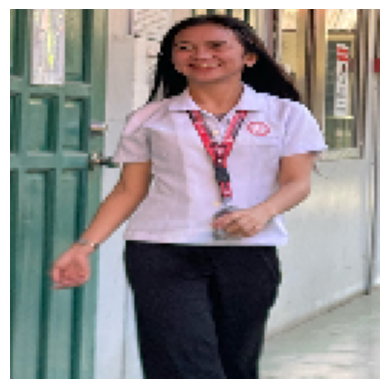

In [12]:
image_path = 'male_female_pic/female2.jpg'

img = tf.keras.utils.load_img(
    image_path, target_size=(128, 128)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0) 

img_array = img_array / 255.0

predictions = model.predict(img_array)
score = predictions[0][0]

if score > 0.5:
    print(f"RESULT: Pencil")
    print(f"accuracy: {100 * score:.2f}%")
else:
    print(f"RESULT: Pen")
    print(f"accuracy: {100 * (1 - score):.2f}%")

import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')
plt.show()

<h1>Reflection</h1>

<h5 style="color: cyan; text-indent: 50px;">
    While building this Pen vs. Pencil classifier, I encountered this one significant problem. It was related to the model's depth, my initial design was too "heavy," causing the training loss to remain high and accuracy fluctuating. I had to refine the architecture to get the model to learn effectively.
</h5>